# Домашнее задание "Продвинутая оптимизация".

### Задание

При фиксированном `seed=42` поэкспериментируйте с параметрами алгоритма [differential_evolution](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.differential_evolution.html): strategy, popsize, mutation.

Постройте графики количества итераций (`nit`) оптимизации [функции ackley](https://en.wikipedia.org/wiki/Ackley_function) от значения параметра.

Подробнее о результате выдачи [тут](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.OptimizeResult.html).

In [ ]:
import numpy as np
from scipy.optimize import differential_evolution
import matplotlib.pyplot as plt

%matplotlib inline

In [ ]:
def ackley(x):
    arg1 = -0.2 * np.sqrt(0.5 * (x[0] ** 2 + x[1] ** 2))
    arg2 = 0.5 * (np.cos(2. * np.pi * x[0]) + np.cos(2. * np.pi * x[1]))
    return -20. * np.exp(arg1) - np.exp(arg2) + 20. + np.e

bounds = [(-10, 10), (-10, 10)]

result = differential_evolution(ackley, bounds, seed=42)
result

             message: Optimization terminated successfully.
             success: True
                 fun: 4.440892098500626e-16
                   x: [ 0.000e+00  0.000e+00]
                 nit: 92
                nfev: 2853
          population: [[ 0.000e+00  0.000e+00]
                       [ 0.000e+00  0.000e+00]
                       ...
                       [ 0.000e+00  0.000e+00]
                       [ 0.000e+00  0.000e+00]]
 population_energies: [ 4.441e-16  4.441e-16 ...  4.441e-16  4.441e-16]

In [ ]:
result.keys()

dict_keys(['x', 'fun', 'nfev', 'nit', 'message', 'success', 'population', 'population_energies'])

In [ ]:
?differential_evolution

**1. Эксперименты со стратегией (остальные параметры по умолчанию)**

In [ ]:
# список всех стратегий алгоритма дифф. эволюции согласно документации
strategies_diff_evol = [
    'best1bin',
    'best1exp',
    'rand1bin',
    'rand1exp',
    'rand2bin',
    'rand2exp',
    'randtobest1bin',
    'randtobest1exp',
    'currenttobest1bin',
    'currenttobest1exp',
    'best2exp',
    'best2bin'
]

In [ ]:
# создаем и наполняем словарь количества итераций по стратегиям
nits_by_strategy = {}
for el in strategies_diff_evol:
    result = differential_evolution(ackley, bounds, seed=42, strategy=el)
    nits_by_strategy[el] = result.nit

nits_by_strategy

{'best1bin': 92,
 'best1exp': 91,
 'rand1bin': 165,
 'rand1exp': 169,
 'rand2bin': 226,
 'rand2exp': 230,
 'randtobest1bin': 103,
 'randtobest1exp': 100,
 'currenttobest1bin': 1000,
 'currenttobest1exp': 1000,
 'best2exp': 164,
 'best2bin': 166}

In [ ]:
nits = [value for value in nits_by_strategy.values()]
nits

[92, 91, 165, 169, 226, 230, 103, 100, 1000, 1000, 164, 166]

In [ ]:
# проверяем исход решений, ВСЕ решения верны
x_by_strategy = {}
for el in strategies_diff_evol:
    res = differential_evolution(ackley, bounds, seed=42, strategy=el)
    x_by_strategy[el] = res.x

x_by_strategy

{'best1bin': array([0., 0.]),
 'best1exp': array([0., 0.]),
 'rand1bin': array([0., 0.]),
 'rand1exp': array([0., 0.]),
 'rand2bin': array([0., 0.]),
 'rand2exp': array([0., 0.]),
 'randtobest1bin': array([0., 0.]),
 'randtobest1exp': array([0., 0.]),
 'currenttobest1bin': array([0., 0.]),
 'currenttobest1exp': array([0., 0.]),
 'best2exp': array([0., 0.]),
 'best2bin': array([0., 0.])}

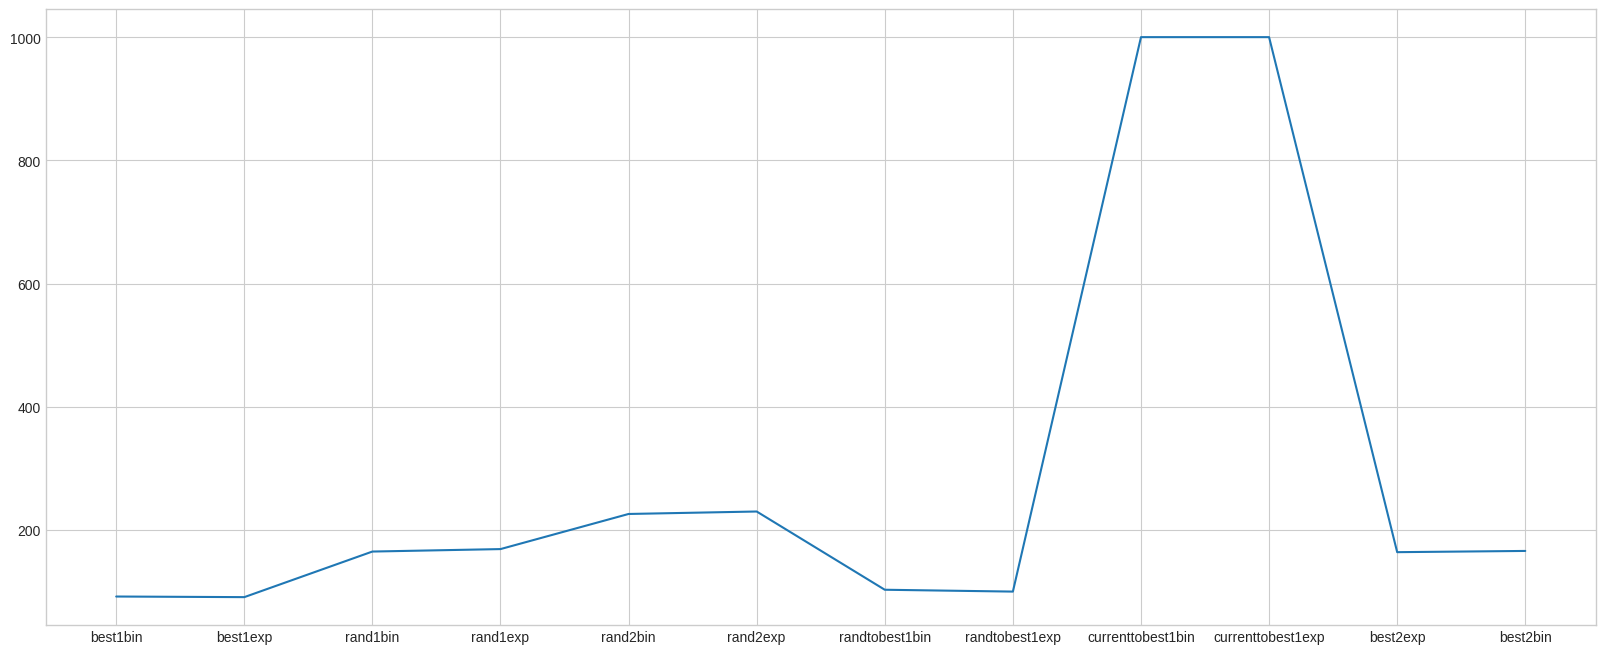

In [ ]:
# минимальное сырое оформление
plt.figure(figsize=(20, 8))

plt.plot(strategies_diff_evol, nits)

plt.show()

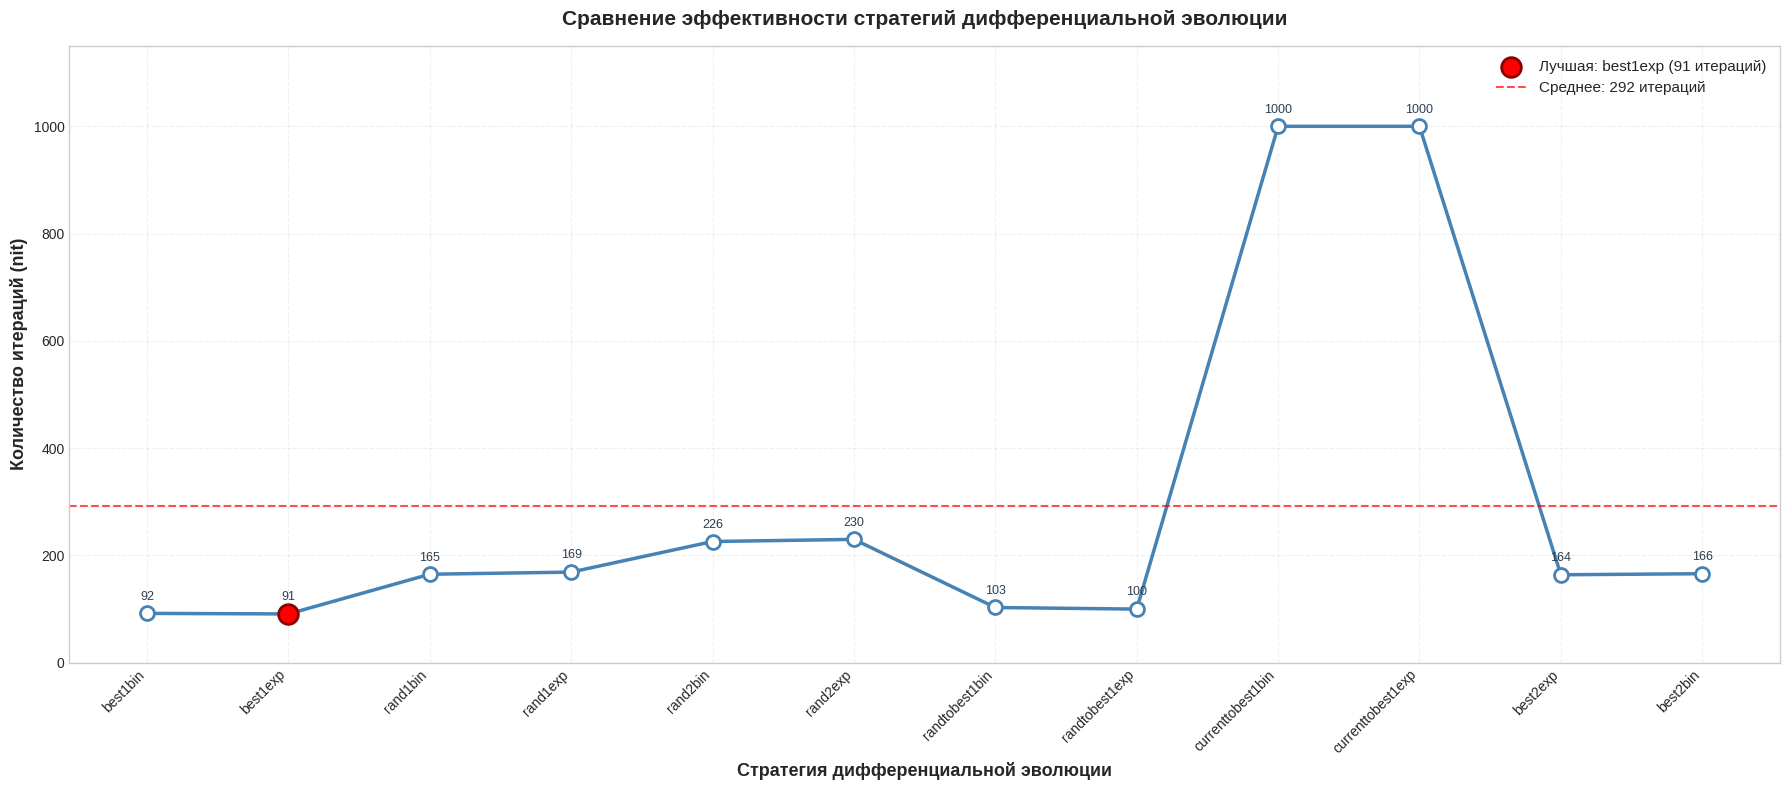

In [ ]:
# === Настройка стиля ===
plt.style.use('seaborn-v0_8-whitegrid')  # красивый фон с сеткой
plt.figure(figsize=(18, 8))

# === 1. Построение графика с маркерами ===
plt.plot(strategies_diff_evol, nits,
         marker='o',           # круглые маркеры
         linestyle='-',        # сплошная линия
         linewidth=2.5,        # толщина линии
         markersize=10,        # размер маркеров
         color='steelblue',    # основной цвет
         markerfacecolor='white',  # белая заливка маркеров
         markeredgewidth=2)    # обводка маркеров

# === 2. Украшение графика ===
plt.xlabel('Стратегия дифференциальной эволюции', fontsize=13, fontweight='bold')
plt.ylabel('Количество итераций (nit)', fontsize=13, fontweight='bold')
plt.title('Сравнение эффективности стратегий дифференциальной эволюции',
          fontsize=15, fontweight='bold', pad=15)

# === 3. Поворот подписей для читаемости ===
plt.xticks(rotation=45, ha='right', fontsize=10)

# === 4. Вертикальная сетка (уже есть от стиля) ===
plt.grid(True, alpha=0.3, linestyle='--')  # полупрозрачная сетка

# === 5. Выделение лучшей стратегии ===
best_idx = np.argmin(nits)  # индекс минимального значения
best_strategy = strategies_diff_evol[best_idx]
best_val = nits[best_idx]

# Красная точка поверх графика
plt.scatter(best_strategy, best_val,
            color='red', s=200, zorder=5,  # zorder - поверх остального
            label=f'Лучшая: {best_strategy} ({best_val} итераций)',
            edgecolor='darkred', linewidth=2)

# === 6. Горизонтальная линия среднего ===
mean_val = np.mean(nits)
plt.axhline(y=mean_val, color='red', linestyle='--', alpha=0.7,
            linewidth=1.5, label=f'Среднее: {mean_val:.0f} итераций')

# === 7. Добавление значений над точками ===
for i, (strategy, val) in enumerate(zip(strategies_diff_evol, nits)):
    plt.text(i, val + 20, str(val),  # +20 - отступ сверху
             ha='center', va='bottom', fontsize=9, color='#2c3e50')

# === 8. Легенда ===
plt.legend(loc='upper right', fontsize=11, framealpha=0.9)

# === 9. Отступы для красоты ===
plt.ylim(0, max(nits) * 1.15)  # 15% запаса сверху для текста
plt.tight_layout()  # автоматическая подгонка

# === 10. Показ ===
plt.show()

2. Эксперименты с popsize (остальные параметры по умолчанию)

In [ ]:
# задаем множители для определения размера популяции
# ниже значение - метод быстрее сходится, но повышается риск сваливания к локальному минимуму
# выше значение - метод дольше работает, но повышается вероятность нахождения глобального минимума
popsizes = [
    5,
    10,
    15,
    20,
    25,
    30,
    35,
    40,
    45,
    50
]

In [ ]:
# создаем и наполняем список количества итераций по значениям popsize
nits_by_popsize = {}
for el in popsizes:
    result1 = differential_evolution(ackley, bounds, seed=42, popsize=el)
    nits_by_popsize[el] = result1.nit

nits_by_popsize

{5: 90,
 10: 105,
 15: 92,
 20: 92,
 25: 95,
 30: 99,
 35: 93,
 40: 102,
 45: 102,
 50: 98}

In [ ]:
nits1 = [value for value in nits_by_popsize.values()]
nits1

[90, 105, 92, 92, 95, 99, 93, 102, 102, 98]

In [ ]:
# проверяем исход решений, ВСЕ решения верны
x_by_popsize = {}
for el in popsizes:
    res1 = differential_evolution(ackley, bounds, seed=42, popsize=el)
    x_by_popsize[el] = res1.x

x_by_popsize

{5: array([0., 0.]),
 10: array([0., 0.]),
 15: array([0., 0.]),
 20: array([0., 0.]),
 25: array([0., 0.]),
 30: array([0., 0.]),
 35: array([0., 0.]),
 40: array([0., 0.]),
 45: array([0., 0.]),
 50: array([0., 0.])}

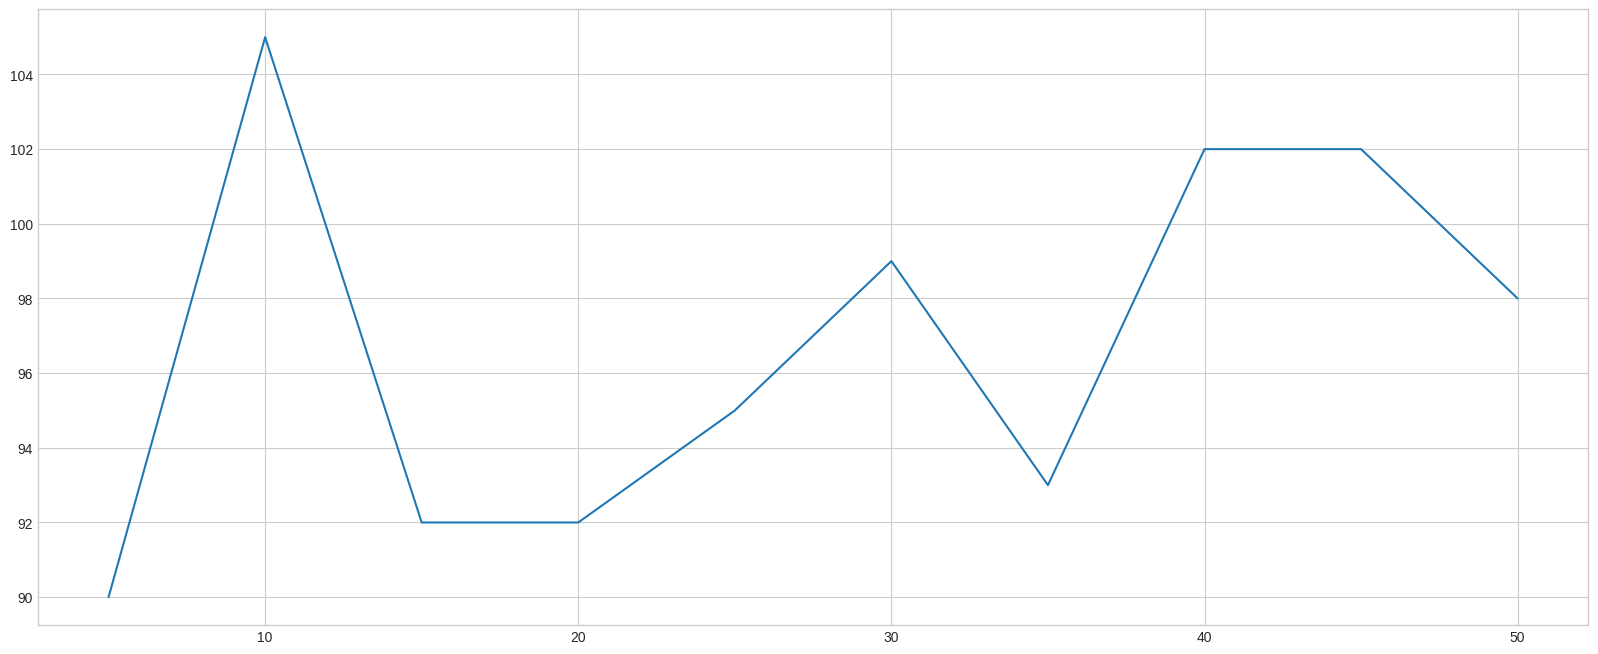

In [ ]:
# минимальное сырое оформление
plt.figure(figsize=(20, 8))

plt.plot(popsizes, nits1)

plt.show()

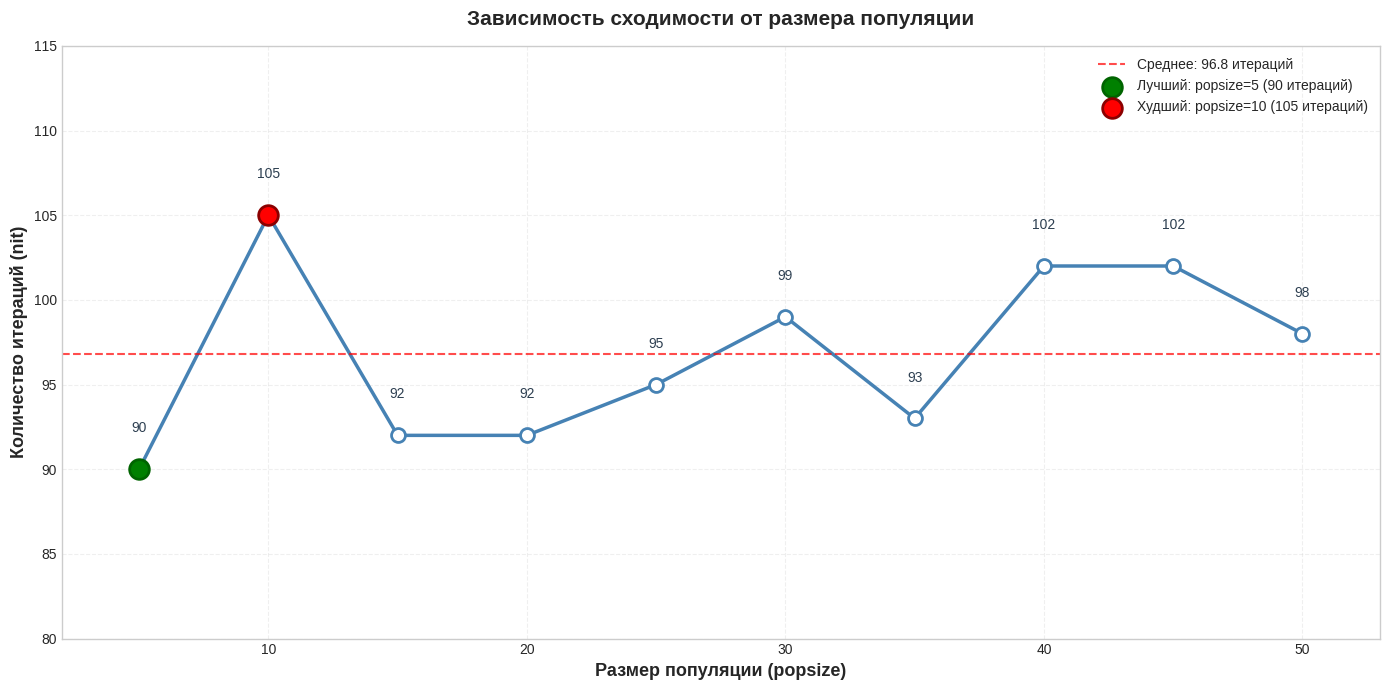

Лучший результат: 90 итераций при popsize=5
Худший результат: 105 итераций при popsize=10
Среднее значение: 96.8 итераций
Разброс значений: 15 итераций


In [ ]:
# === 1. Настройка стиля ===
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(14, 7))

# === 2. Основной график (линия + маркеры) ===
plt.plot(popsizes, nits1,
         marker='o',              # круглые маркеры
         linestyle='-',           # сплошная линия
         linewidth=2.5,           # толщина линии
         markersize=10,           # размер маркеров
         color='steelblue',       # основной цвет
         markerfacecolor='white', # белая заливка маркеров
         markeredgewidth=2)       # обводка маркеров

# === 3. Оформление осей ===
plt.xlabel('Размер популяции (popsize)', fontsize=13, fontweight='bold')
plt.ylabel('Количество итераций (nit)', fontsize=13, fontweight='bold')
plt.title('Зависимость сходимости от размера популяции',
          fontsize=15, fontweight='bold', pad=15)

# === 4. Сетка ===
plt.grid(True, alpha=0.3, linestyle='--')

# === 5. Значения над точками ===
for i, (p, val) in enumerate(zip(popsizes, nits1)):
    plt.text(p, val + 2, str(val),  # +2 отступ (маленький, т.к. данные компактные)
             ha='center', va='bottom', fontsize=10, color='#2c3e50')

# === 6. Линия среднего значения ===
mean_val = np.mean(nits1)
plt.axhline(y=mean_val, color='red', linestyle='--', alpha=0.7,
            linewidth=1.5, label=f'Среднее: {mean_val:.1f} итераций')

# === 7. Выделение лучшего и худшего результатов ===
best_idx = np.argmin(nits1)  # индекс минимального значения
worst_idx = np.argmax(nits1)  # индекс максимального значения

# Зеленая точка для лучшего
plt.scatter(popsizes[best_idx], nits1[best_idx],
            color='green', s=200, zorder=5,
            label=f'Лучший: popsize={popsizes[best_idx]} ({nits1[best_idx]} итераций)',
            edgecolor='darkgreen', linewidth=2)

# Красная точка для худшего
plt.scatter(popsizes[worst_idx], nits1[worst_idx],
            color='red', s=200, zorder=5,
            label=f'Худший: popsize={popsizes[worst_idx]} ({nits1[worst_idx]} итераций)',
            edgecolor='darkred', linewidth=2)

# === 8. Легенда ===
plt.legend(loc='upper right', fontsize=10, framealpha=0.9)

# === 9. Оптимальный масштаб (без пустоты внизу) ===
plt.ylim(80, 115)  # специально под ваши данные (минимум 90, максимум 105)
plt.xlim(2, 53)    # чуть шире крайних точек
plt.tight_layout()

# === 10. Показ ===
plt.show()

# === 11. Дополнительная статистика ===
print(f"Лучший результат: {nits1[best_idx]} итераций при popsize={popsizes[best_idx]}")
print(f"Худший результат: {nits1[worst_idx]} итераций при popsize={popsizes[worst_idx]}")
print(f"Среднее значение: {mean_val:.1f} итераций")
print(f"Разброс значений: {max(nits1) - min(nits1)} итераций")

3. Эксперименты с mutation (остальные параметры по умолчанию)

In [ ]:
# задаем mutation (по другому, дифф.вес F), можно конкретное из [0, 2) или диапазон в виде кортежа
# уменьшение - сужает область поиска, способствуя уточнению найденного решения,
# но повышает риск преждевременной сходимости к неоптимальному результату
# повышение - все наоборот

mutations = [
    0.5,
    0.6,
    0.7,
    0.8,
    0.9,
    1.0
]

In [ ]:
# создаем и наполняем список количества итераций по значениям mutation
nits_by_mutation = {}
for el in mutations:
    result2 = differential_evolution(ackley, bounds, seed=42, mutation=el)
    nits_by_mutation[el] = result2.nit

nits_by_mutation

{0.5: 58, 0.6: 76, 0.7: 90, 0.8: 113, 0.9: 136, 1.0: 157}

In [ ]:
nits2 = [value for value in nits_by_mutation.values()]
nits2

[58, 76, 90, 113, 136, 157]

In [ ]:
# проверяем исход решений, ВСЕ решения верны
x_by_mutation = {}
for el in mutations:
    res2 = differential_evolution(ackley, bounds, seed=42, mutation=el)
    x_by_mutation[el] = res2.x

x_by_mutation

{0.5: array([0., 0.]),
 0.6: array([0., 0.]),
 0.7: array([0., 0.]),
 0.8: array([0., 0.]),
 0.9: array([0., 0.]),
 1.0: array([0., 0.])}

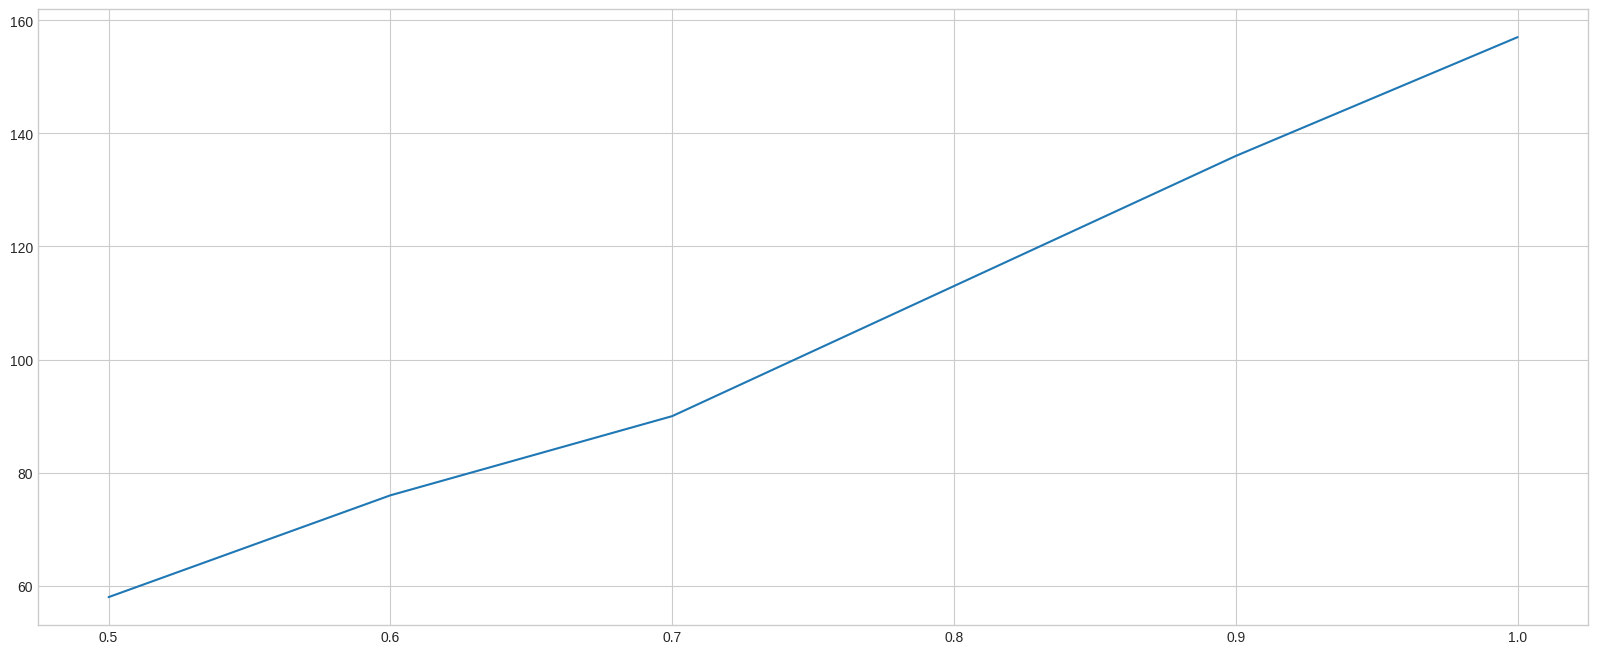

In [ ]:
# минимальное сырое оформление
plt.figure(figsize=(20, 8))

plt.plot(mutations, nits2)

plt.show()

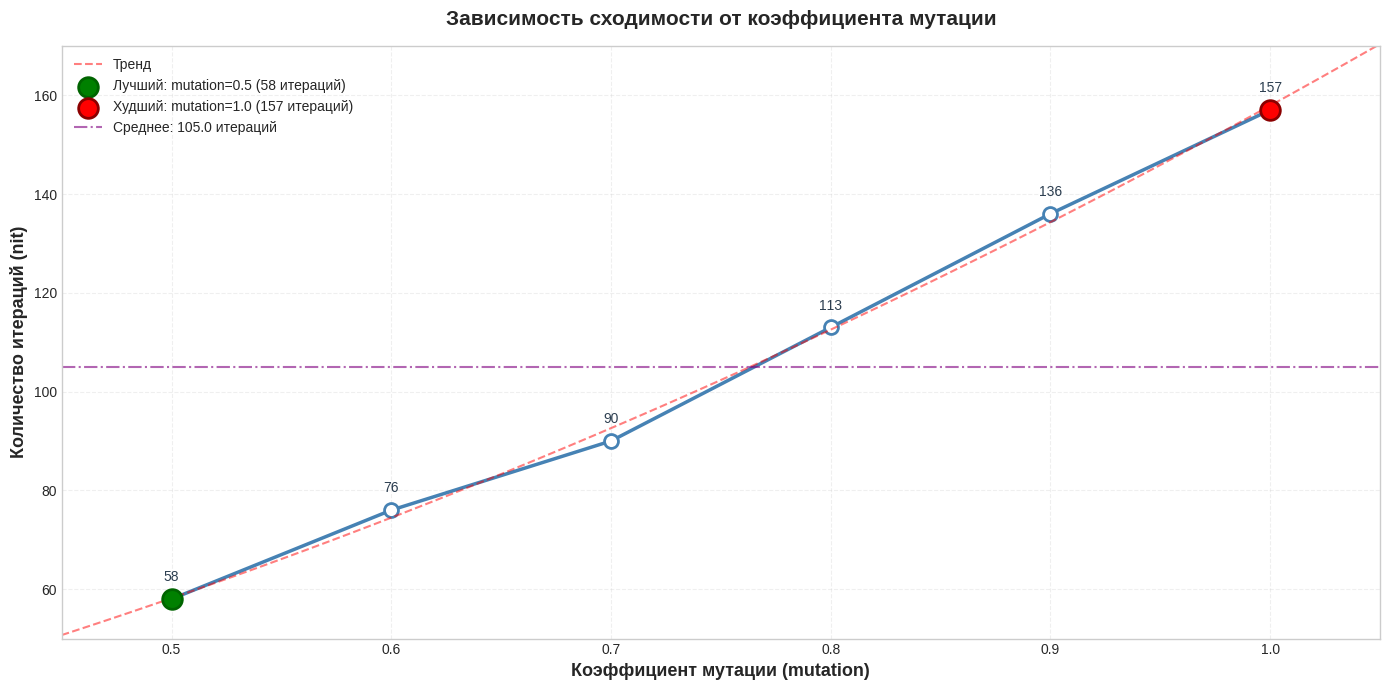

СТАТИСТИКА ЭКСПЕРИМЕНТОВ
Лучший результат: 58 итераций при mutation=0.5
Худший результат: 157 итераций при mutation=1.0
Среднее значение: 105.0 итераций
Разброс: 99 итераций
Рост количества итераций: 99 итераций

ПРАКТИЧЕСКИЙ ВЫВОД
↗ При увеличении mutation с 0.5 до 1.0
  количество итераций выросло на 99 шт.
  (с 58 до 157)

📌 Рекомендация: для вашей задачи оптимальное значение mutation ~ 0.5
   (минимальное количество итераций - 58)


In [ ]:
# оформление информативное

# === 1. Настройка стиля ===
plt.style.use('seaborn-v0_8-whitegrid')  # чистый стиль с сеткой
plt.figure(figsize=(14, 7))

# === 2. Основной график (линия + маркеры) ===
plt.plot(mutations, nits2,
         marker='o',              # круглые маркеры
         linestyle='-',           # сплошная линия
         linewidth=2.5,           # толщина линии
         markersize=10,           # размер маркеров
         color='steelblue',       # основной цвет
         markerfacecolor='white', # белая заливка маркеров
         markeredgewidth=2)       # обводка маркеров

# === 3. Оформление осей ===
plt.xlabel('Коэффициент мутации (mutation)', fontsize=13, fontweight='bold')
plt.ylabel('Количество итераций (nit)', fontsize=13, fontweight='bold')
plt.title('Зависимость сходимости от коэффициента мутации',
          fontsize=15, fontweight='bold', pad=15)

# === 4. Сетка ===
plt.grid(True, alpha=0.3, linestyle='--')  # полупрозрачная сетка

# === 5. Значения над точками ===
for i, (m, val) in enumerate(zip(mutations, nits2)):
    plt.text(m, val + 3, str(val),  # +3 отступ сверху
             ha='center', va='bottom', fontsize=10, color='#2c3e50')

# === 6. Линия тренда (полиномиальная аппроксимация) ===
# Показывает общую тенденцию роста
z = np.polyfit(mutations, nits2, 2)  # квадратичная аппроксимация
p = np.poly1d(z)
x_trend = np.linspace(min(mutations) - 0.05, max(mutations) + 0.05, 100)
plt.plot(x_trend, p(x_trend), '--', color='red', alpha=0.5,
         linewidth=1.5, label='Тренд')

# === 7. Выделение лучшего и худшего результатов ===
best_idx = np.argmin(nits2)   # индекс минимального значения
worst_idx = np.argmax(nits2)  # индекс максимального значения

# Зеленая точка для лучшего (минимальное количество итераций)
plt.scatter(mutations[best_idx], nits2[best_idx],
            color='green', s=200, zorder=5,
            label=f'Лучший: mutation={mutations[best_idx]:.1f} ({nits2[best_idx]} итераций)',
            edgecolor='darkgreen', linewidth=2)

# Красная точка для худшего (максимальное количество итераций)
plt.scatter(mutations[worst_idx], nits2[worst_idx],
            color='red', s=200, zorder=5,
            label=f'Худший: mutation={mutations[worst_idx]:.1f} ({nits2[worst_idx]} итераций)',
            edgecolor='darkred', linewidth=2)

# === 8. Линия среднего значения ===
mean_val = np.mean(nits2)
plt.axhline(y=mean_val, color='purple', linestyle='-.', alpha=0.6,
            linewidth=1.5, label=f'Среднее: {mean_val:.1f} итераций')

# === 9. Легенда ===
plt.legend(loc='upper left', fontsize=10, framealpha=0.9)  # сместили влево, чтобы не мешать

# === 10. Оптимальный масштаб (без пустоты) ===
plt.ylim(50, 170)  # чуть ниже минимума (58) и чуть выше максимума (157)
plt.xlim(0.45, 1.05)  # чуть шире крайних точек
plt.tight_layout()

# === 11. Показ ===
plt.show()

# === 12. Статистика и вывод ===
print("=" * 50)
print("СТАТИСТИКА ЭКСПЕРИМЕНТОВ")
print("=" * 50)
print(f"Лучший результат: {nits2[best_idx]} итераций при mutation={mutations[best_idx]:.1f}")
print(f"Худший результат: {nits2[worst_idx]} итераций при mutation={mutations[worst_idx]:.1f}")
print(f"Среднее значение: {mean_val:.1f} итераций")
print(f"Разброс: {max(nits2) - min(nits2)} итераций")
print(f"Рост количества итераций: {nits2[-1] - nits2[0]} итераций")

# === 13. Практический вывод ===
print("\n" + "=" * 50)
print("ПРАКТИЧЕСКИЙ ВЫВОД")
print("=" * 50)
print(f"↗ При увеличении mutation с {mutations[0]:.1f} до {mutations[-1]:.1f}")
print(f"  количество итераций выросло на {nits2[-1] - nits2[0]} шт.")
print(f"  (с {nits2[0]} до {nits2[-1]})")
print(f"\n📌 Рекомендация: для вашей задачи оптимальное значение mutation ~ {mutations[best_idx]:.1f}")
print(f"   (минимальное количество итераций - {nits2[best_idx]})")

**Проверим решение с использованием вышенайденных лучших значений параметров**

In [ ]:
best_strategy = min(nits_by_strategy, key=nits_by_strategy.get)
best_strategy

'best1exp'

In [ ]:
best_popsize = min(nits_by_popsize, key=nits_by_popsize.get)
best_popsize

5

In [ ]:
best_mutation = min(nits_by_mutation, key=nits_by_mutation.get)
best_mutation

0.5

In [ ]:
best_result = differential_evolution(
    ackley, bounds, seed=42, strategy=best_strategy, popsize=best_popsize, mutation=best_mutation
    )
best_result

             message: Optimization terminated successfully.
             success: True
                 fun: 4.440892098500626e-16
                   x: [ 0.000e+00  0.000e+00]
                 nit: 61
                nfev: 683
          population: [[ 0.000e+00  0.000e+00]
                       [ 0.000e+00  0.000e+00]
                       ...
                       [ 0.000e+00  0.000e+00]
                       [ 0.000e+00  0.000e+00]]
 population_energies: [ 4.441e-16  4.441e-16  4.441e-16  4.441e-16
                        4.441e-16  4.441e-16  4.441e-16  4.441e-16
                        4.441e-16  4.441e-16]

In [ ]:
# сравниваем кол-во итераций best_result с минимальными итерациями на предыдущих экспериментах
print(best_result.nit < min(nits))
print(best_result.nit < min(nits1))
print(best_result.nit < min(nits2))

True
True
False


In [ ]:
# всего 3 итерации разница, где false
best_result.nit - min(nits2)

3

ВЫВОД: применение лучших значений вышеуказанных параметров позволяет уменьшить количество итераций для успешного нахождения верного решения

### Дополнительное задание


Поэкспериментируйте с параметрами и оптимизацией через [minimize](https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize.html):

In [ ]:
from scipy.optimize import minimize

x0 = [0,0]

result_m = minimize(ackley, x0,  method='Nelder-Mead')
result_m

       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 4.440892098500626e-16
             x: [ 0.000e+00  0.000e+00]
           nit: 8
          nfev: 17
 final_simplex: (array([[ 0.000e+00,  0.000e+00],
                       [-1.607e-05, -8.453e-06],
                       [-1.404e-06, -3.113e-05]]), array([ 4.441e-16,  5.136e-05,  8.816e-05]))

In [ ]:
# Метод Пауэлла (сопряжённых направлений)
result_powell = minimize(ackley, x0,  method='Powell')
result_powell

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 4.440892098500626e-16
       x: [ 0.000e+00  0.000e+00]
     nit: 1
   direc: [[ 1.000e+00  0.000e+00]
           [ 0.000e+00  1.000e+00]]
    nfev: 61

In [ ]:
# Квадратичная аппроксимация (ограничения)
result_cobyqa = minimize(ackley, x0,  method='COBYQA')
result_cobyqa

 message: The lower bound for the trust-region radius has been reached
 success: True
  status: 0
     fun: 4.440892098500626e-16
       x: [ 0.000e+00  0.000e+00]
     nit: 21
   maxcv: 0.0
    nfev: 29

In [ ]:
# функция с градиентов функции Аккли
def ackley_gradient(x):
    """
    Градиент (первая производная) функции Аккли.
    Возвращает вектор [df/dx0, df/dx1]
    """
    x0, x1 = x[0], x[1]

    # Вспомогательные вычисления (повторяем часть из функции)
    r = np.sqrt(0.5 * (x0**2 + x1**2))
    arg1 = -0.2 * r
    arg2 = 0.5 * (np.cos(2. * np.pi * x0) + np.cos(2. * np.pi * x1))

    # Производная exp(arg1) по x0 и x1
    # d/dx0 exp(-0.2*r) = exp(-0.2*r) * (-0.2) * dr/dx0
    # dr/dx0 = x0 / (2*r) при r>0, но для r=0 нужно аккуратно
    if r > 1e-15:
        dr_dx0 = x0 / (2 * r)
        dr_dx1 = x1 / (2 * r)
    else:
        dr_dx0 = 0.0
        dr_dx1 = 0.0

    d_exp_arg1_dx0 = np.exp(arg1) * (-0.2) * dr_dx0
    d_exp_arg1_dx1 = np.exp(arg1) * (-0.2) * dr_dx1

    # Производная exp(arg2) по x0 и x1
    # d/dx0 exp(arg2) = exp(arg2) * d(arg2)/dx0
    # d(arg2)/dx0 = -pi * sin(2*pi*x0)
    d_arg2_dx0 = -np.pi * np.sin(2. * np.pi * x0)
    d_arg2_dx1 = -np.pi * np.sin(2. * np.pi * x1)

    d_exp_arg2_dx0 = np.exp(arg2) * d_arg2_dx0
    d_exp_arg2_dx1 = np.exp(arg2) * d_arg2_dx1

    # Производная всей функции: f = -20*exp(arg1) - exp(arg2) + 20 + e
    df_dx0 = -20. * d_exp_arg1_dx0 - d_exp_arg2_dx0
    df_dx1 = -20. * d_exp_arg1_dx1 - d_exp_arg2_dx1

    return np.array([df_dx0, df_dx1])

In [ ]:
# методы использующие производные
first_order_methods = [
    'CG',            # Метод сопряжённых градиентов
    'BFGS',          # Квазиньютоновский метод (по умолчанию)
    'L-BFGS-B',      # L-BFGS с ограничениями на переменные
    'TNC',           # Усечённый метод Ньютона (с ограничениями)
    'SLSQP'          # Последовательное квадратичное программирование
]

In [ ]:
# Метод сопряжённых градиентов
result_cg = minimize(ackley, x0, method='CG', jac=ackley_gradient)
result_cg

 message: Optimization terminated successfully.
 success: True
  status: 0
     fun: 4.440892098500626e-16
       x: [ 0.000e+00  0.000e+00]
     nit: 0
     jac: [ 0.000e+00  0.000e+00]
    nfev: 1
    njev: 1

In [ ]:
print(f"Решение: {result_cg.x}")
print(f"Значение: {result_cg.fun}")
print(f"Итераций: {result_cg.nit}")

Решение: [0. 0.]
Значение: 4.440892098500626e-16
Итераций: 0


In [ ]:
# Квазиньютоновский метод (по умолчанию)
result_bfcg = minimize(ackley, x0, method='BFGS', jac=ackley_gradient)
result_bfcg

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 4.440892098500626e-16
        x: [ 0.000e+00  0.000e+00]
      nit: 0
      jac: [ 0.000e+00  0.000e+00]
 hess_inv: [[1 0]
            [0 1]]
     nfev: 1
     njev: 1

In [ ]:
print(f"Решение: {result_bfcg.x}")
print(f"Значение: {result_bfcg.fun}")
print(f"Итераций: {result_bfcg.nit}")

Решение: [0. 0.]
Значение: 4.440892098500626e-16
Итераций: 0


In [ ]:
# L-BFGS с ограничениями на переменные
result_lbfcg = minimize(ackley, x0, method='L-BFGS-B', jac=ackley_gradient)
result_lbfcg

  message: CONVERGENCE: NORM OF PROJECTED GRADIENT <= PGTOL
  success: True
   status: 0
      fun: 4.440892098500626e-16
        x: [ 0.000e+00  0.000e+00]
      nit: 0
      jac: [ 0.000e+00  0.000e+00]
     nfev: 1
     njev: 1
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>

In [ ]:
print(f"Решение: {result_lbfcg.x}")
print(f"Значение: {result_lbfcg.fun}")
print(f"Итераций: {result_lbfcg.nit}")

Решение: [0. 0.]
Значение: 4.440892098500626e-16
Итераций: 0


In [ ]:
# Усечённый метод Ньютона (с ограничениями)
result_TNC = minimize(ackley, x0, method='TNC', jac=ackley_gradient)
result_TNC

 message: Local minimum reached (|pg| ~= 0)
 success: True
  status: 0
     fun: 4.440892098500626e-16
       x: [ 0.000e+00  0.000e+00]
     nit: 0
     jac: [ 0.000e+00  0.000e+00]
    nfev: 1

In [ ]:
print(f"Решение: {result_TNC.x}")
print(f"Значение: {result_TNC.fun}")
print(f"Итераций: {result_TNC.nit}")

Решение: [0. 0.]
Значение: 4.440892098500626e-16
Итераций: 0


In [ ]:
# Последовательное квадратичное программирование
result_SLSQP = minimize(ackley, x0, method='SLSQP', jac=ackley_gradient)
result_SLSQP

     message: Optimization terminated successfully
     success: True
      status: 0
         fun: 4.440892098500626e-16
           x: [ 0.000e+00  0.000e+00]
         nit: 1
         jac: [ 0.000e+00  0.000e+00]
        nfev: 1
        njev: 1
 multipliers: []

In [ ]:
print(f"Решение: {result_SLSQP.x}")
print(f"Значение: {result_SLSQP.fun}")
print(f"Итераций: {result_SLSQP.nit}")

Решение: [0. 0.]
Значение: 4.440892098500626e-16
Итераций: 1
